# **Modeling Logistic Regressions**

## Overview
This notebook presents a comprehensive implementation of ****Modeling Logistic Regressions****. It demonstrates the fundamental mechanics and technical approaches used to solve problems within this domain.

## Objectives
- Implement foundational classification algorithms.
- Preprocess data for classification tasks.
- Evaluate model performance using standard accuracy metrics.


Logistic regression, despite its name, is a classification model rather than regression model. Logistic regression is a simple and more efficient method for binary and linear classification problems. It is a classification model, which is very easy to realize and achieves very good performance with linearly separable classes.



--

## Goals
In this implementation, you will:
- implement your first classifier
- understand the concept of region boundary

In this Notebook we are going to see how this algorithm works with a simple example, using the Python library "scikit-learn", especifically the ["LogisticRegression" function](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

First, we are going to import some libraries and functions that we will use:

*   `Numpy`, that allows us to work with arrays
*   The `LogisticRegression` function from the linear_model package in the Scikit-learn library
*   The `pylot` package from Matplotlib, that will allow us to plot some results
*   `Seaborn` and the `metrics` function from the Scikit-learn library, that allows us to plot the confusion matrix
*   The `expit` function from the special package in the Scipy library



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
from scipy.special import expit

Then we define some functions that will be useful to plot the results of the models we will create

In [2]:
# Create a meshgrid with values ranging. from 0 to the maximum values of x and y
def make_meshgrid(x, y, h=.02):
    x_min, x_max = 0, x.max() + 1
    y_min, y_max = 0, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

# Plot the contours of a function clf within the values of xx and yy in the figure ax
def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

# Plot a figure with the points (X,Y) and the classification function
def plot_figure(X, Y, clf, dataset):
  fig, ax = plt.subplots(figsize=(10, 7))
  # title for the plots
  title = ('Decision surface of LR '+dataset)
  # Set-up grid for plotting.
  X0, X1 = X[:, 0], X[:, 1]
  xx, yy = make_meshgrid(X0, X1)

  plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
  ax.scatter(X0, X1, c=Y, cmap=plt.cm.coolwarm, s=50, edgecolors='face')
  ax.set_ylabel('x2')
  ax.set_xlabel('x1')
  ax.set_xticks(np.arange(0, X0.max() + 1, 10))
  ax.set_yticks(np.arange(0, X1.max() + 1, 10))
  ax.set_title(title)
  plt.show()

## **DATA DEFINITION**

We are presented with a simple 1 dimensional problem with 2 classes of observations. We have given an automated program the  grades to decide if the students passed or failed, but this program has a glitch and sometimes the result is not very accurate. We have two resulting datasets:

*   Training data, where **XTrain** contains the features of the training samples, in this case the grades, and **yTrain** contains the ground truth of these samples, in this case if they passed or failed. This dataset will be used to train the model.
*   Testing data, where **XTest** contains the features of the training samples, in this case the grades, and **yTest** contains the ground truth of these samples, in this case if they passed or failed. This dataset will be used to verify how accurate the trained model is.

In [3]:
# Parameters of training data
XTrain = np.array([[0],[0.6],[1],[1.25],[1.7],[2.1],[2.9],[3.5],[3.8],[4],[4.5],[4.6],[4.8],[4.9],[4.9],[5],[5.3],[6.1],[6.4],[6.9],[7.3],[7.5],[8],[8.6],[9],[9.4],[10]])
# Ground truth of training data
yTrain = np.array([ 0,   0,   0,   0,     0,    0,    0,    0,    0,   0,   0,    1,    0,    1,    0,    1,   1,   1,    1,    1,    1,    1,    1,   1,   1,   1,  1])

# Parameters of testing data
XTest = np.array([[0],[0.3],[1.1],[1.45],[1.77],[2.2],[2.75],[3.3],[3.9],[4.1],[4.55],[4.66],[4.78],[4.9],[4.99],[5.05],[5.35],[6.4],[6.6],[7],[7.2],[7.8],[8.2],[8.5],[9.3],[9.8],[10]])
# Ground truth of testing data
yTest = np.array([ 0,   0,    0,     0,    0,     0,    0,     0,    0,    0,     0,    0,     0,     0,    0,     1,     1,     1,    1,   1,   1,    1,    1,    1,    1,    1,   1])

To start, we have an example of how to create a basic regression function using the [**"LogisticRegression"**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) function. Next, the mean error percentage is computed for the train data and the fitted function and the training data is plotted.

In [4]:
# Fit the classifier
clf = LogisticRegression()
clf.fit(XTrain, yTrain)

# Check predictions for training data
res = clf.predict(XTrain)
# Calculate % of correct predictions using (number of correct predictions / number of predictions * 100)
print("% of correct predictions with training data")
print((100/len(res)*np.count_nonzero(yTrain == res)))

% of correct predictions with training data
88.88888888888889


Now we have the model created and we know the % of correct predictions of the training data. **Which is the % of correct predictions for the testing data? Round the value to 2 decimals.**

In [5]:
# Check predictions for testing data
res =  clf.predict(XTest)
# Calculate % of correct predictions using (number of correct predictions / number of predictions * 100)
print("% of correct predictions with testing data")
pred = 100/len(res)*np.count_nonzero(yTest == res)
print(round(pred, 2))

% of correct predictions with testing data
92.59


We can call a Logistic Regression a Linear Regression model but the Logistic Regression uses a more complex cost function, this cost function can be defined as the ‘Sigmoid function’ or also known as the ‘logistic function’ instead of a linear function.

**The hypothesis of logistic regression tends it to limit the cost function between 0 and 1. Therefore linear functions fail to represent it as it can have a value greater than 1 or less than 0 which is not possible as per the hypothesis of logistic regression.**

Now that we have trained the model, we are going to plot this Sigmoid function (red line) and the training (green circles) and testing (blue triangles) data for this model and analyze the results.

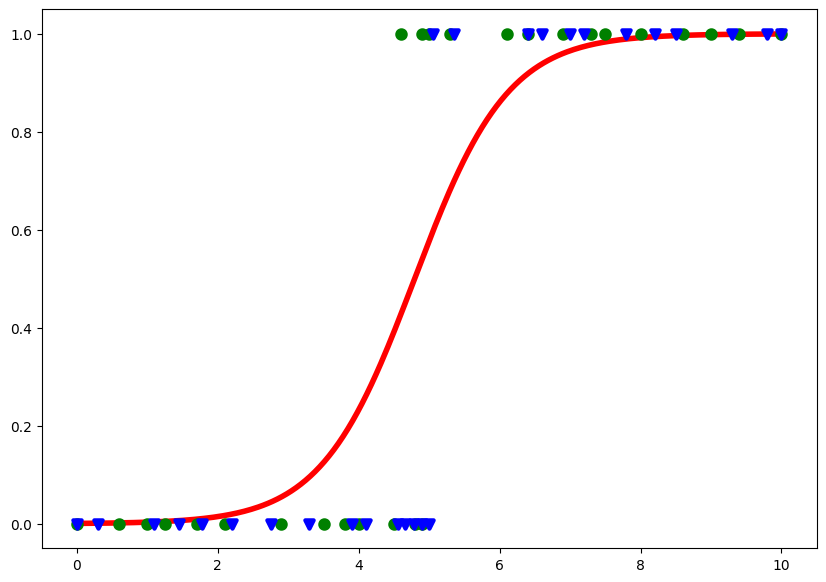

In [6]:
# and plot the resulting sigmoid
plt.figure(1, figsize=(10, 7))
plt.clf()
plt.scatter(XTrain.ravel(), yTrain, color="green", zorder=20, linewidths = 3)
plt.scatter(XTest.ravel(), yTest, color="blue", zorder=20, marker = 'v', linewidths = 3)
X_test = np.linspace(0, 10, 300)

loss = expit(X_test * clf.coef_ + clf.intercept_).ravel()
plt.plot(X_test, loss, color="red", linewidth=4)



--

Now that we've seen an example of how this works, we are going to see a slightly more complex problem.

## **DATA DEFINITION**

In this case, we are presented with a simple 2 dimensional problem with 2 classes of observations. We have two datasets:

*   Training data, where **XTrain** contains the features of the training samples and **yTrain** contains the ground truth of these samples. This dataset will be used to train the logistic regression models.
*   Testing data, where **XTest** contains the features of the testing samples and **yTest** contains the ground truth of these samples. This dataset will be used to verify how accurate the trained logistic regression models are.



In [7]:
# Parameters of training data
XTrain2 = np.array([[ 4, 43], [ 5, 12], [10, 31], [10, 20], [20, 37], [16, 10], [22, 18], [24,  4], [28,  9], [33, 19], [38,  5], [15, 47], [30, 32], [52,  6], [ 6, 60], \
                   [50,  8], [23, 58], [26, 50], [30, 40], [35, 28], [42, 61], [36, 50], [43, 37], [46, 45], [50, 22], [55, 35], [65, 25], [70, 46], [27, 37], [24, 23], [38, 19]])
# Ground truth of training data
yTrain2 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Parameters of testing data
XTest2 = np.array([[3, 56], [4, 18], [6, 5], [10, 32], [16, 19], [18, 3], [33, 6], [28, 15], [28, 25], [24, 30], [25, 57], [50, 3], \
                  [20, 53], [28, 55], [35, 45], [38, 27], [37, 13], [40, 3], [57, 5], [53, 29], [50, 46], [64, 34], [65, 57], [31, 30]])
# Ground truth of testing data
yTest2 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# **Modeling Logistic Regressions**

Define a new model now with the 2D data and compute the % of correct predictions of the training and testing data. **Visualize the plot and analize the results.**

$\color{red}{\textbf{Training Data Plot:}}$
**The decision boundary does an excellent job of separating the blue and red points, indicating that the model has effectively learned the underlying data pattern.**

**However, it is not perfect—some blue points fall into the red region and a few red points into the blue region. These are the misclassified samples, which explain why the accuracy is high (90.32%).**

$\color{red}{\textbf{Testing Data Plot:}}$
**When tested on unseen data, the model maintains strong performance. The same decision boundary learned from training correctly classifies most points, with only a few misclassifications near the border.**

**The slightly lower accuracy of 83.33% is expected, as models often perform a bit worse on new data. This shows that the model generalizes well and avoids overfitting, capturing the true relationship between the two features effectively.**

% of correct predictions with training data
90.32


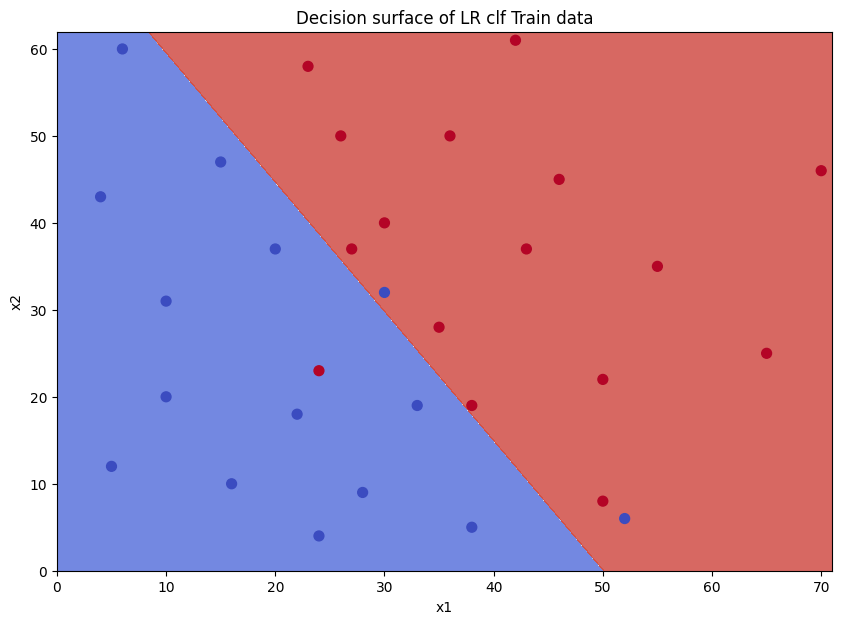

% of correct predictions with training data
83.33


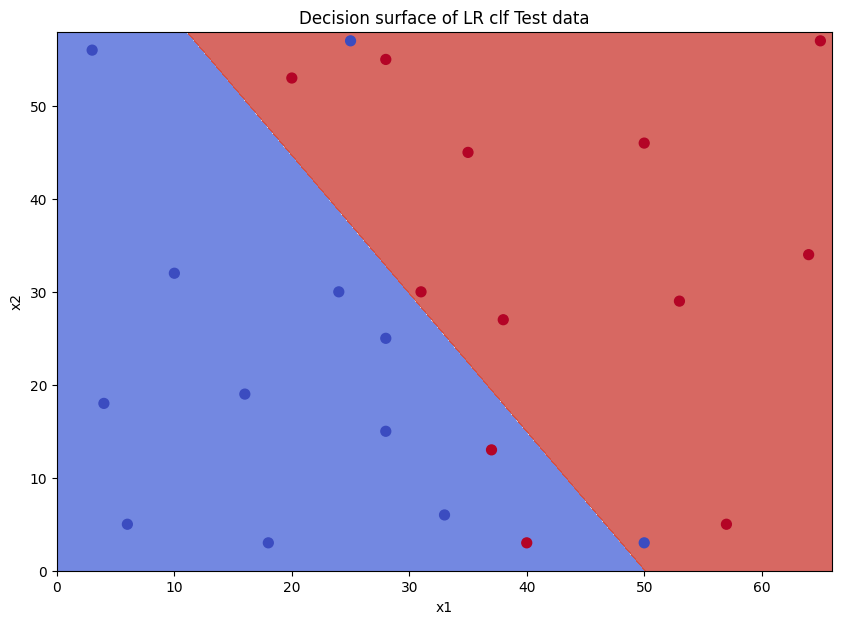

In [13]:

# Create the logistic regression model
# Fit the classifier
clf = LogisticRegression()
clf.fit(XTrain2, yTrain2)

# Check predictions for training data
res1 = clf.predict(XTrain2)
# Calculate % of correct predictions using (number of correct predictions / number of predictions * 100)
print("% of correct predictions with training data")
pred_train = ((100/len(res1)*np.count_nonzero(yTrain2 == res1)))
print (round(pred_train, 2))

# Plot the resulting polynomial model of degree 3 with the training and testing datasets
plot_figure(XTrain2, yTrain2, clf, 'clf Train data')
# Check predictions for test data

# Fit the classifier


# Check predictions for training data
res2 = clf.predict(XTest2)
# Calculate % of correct predictions using (number of correct predictions / number of predictions * 100)
print("% of correct predictions with training data")
pred_test = ((100/len(res2)*np.count_nonzero(yTest2 == res2)))
print (round(pred_test, 2))

#Plot the resulting polynomial model of degree 3 with the training and testing datasets
plot_figure(XTest2, yTest2, clf, 'clf Test data')

Here we have the plot of the confusion matrix of the training data results. Plot the *confusion matrix for the testing data using the 'rocket_r' color palette*, and, with the previous plots, further analyze the results gotten.

$\color{red}{\textbf{Training Data :}}$

$\color{red}{\textbf{True Positives (13): It correctly identified 13 blue dots (Class 0) as blue.}}$$\color{red}{\textbf{True Negatives (15): It correctly identified 15 red dots (Class 1) as red.}}$$\color{red}{\textbf{False Positives (1): It made 1 mistake by calling a red dot blue.}}$$\color{red}{\textbf{False Negatives (2): It made 2 mistakes by calling a blue dot red.}}$

$\color{red}{\textbf{Analysis: The model correctly classified 28 out of 31 training instances, resulting in an accuracy of 90.32%.}}$
$\color{red}{\textbf{The presence of 3 misclassifications (2 FP and 1 FN) indicates that the data is not perfectly separable with a linear boundary, but the model has achieved a strong fit.}}$

$\color{red}{\textbf{Testing Data : }}$

$\color{red}{\textbf{True Positives (10): It correctly identified 10 new blue dots (Class 0) as blue.}}$$\color{red}{\textbf{True Negatives (10): It correctly identified 10 new red dots (Class 1) as red.}}$$\color{red}{\textbf{False Positives (2): It made 2 mistakes by calling a new red dot blue.}}$$\color{red}{\textbf{False Negatives (2): It made 2 mistakes by calling a new blue dot red.}}$

$\color{red}{\textbf{Analysis: On the test set, the model correctly classified 20 out of 24 instances, confirming the 83.33% accuracy.}}$

$\color{red}{\textbf{The matrix reveals that the prediction errors are balanced, with an equal number of False Positives and False Negatives.The strong performance on the test set indicates that the model has generalized well from the training data.}}$

Text(0.5, 1.0, 'Confusion matrix training data')

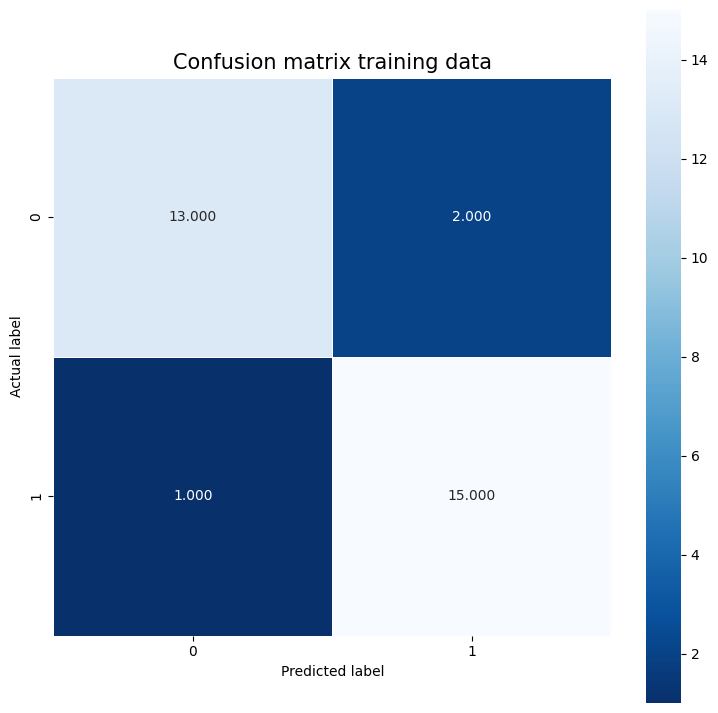

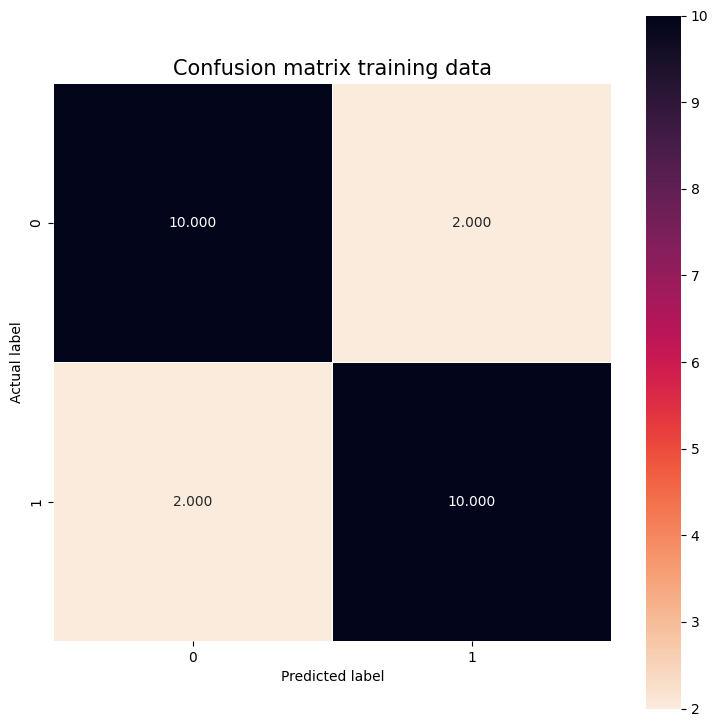

In [14]:
#Plot the confusion matrix of the training data
res = clf.predict(XTrain2)
cm = metrics.confusion_matrix(yTrain2, res)
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label')
plt.title("Confusion matrix training data", size = 15)


res = clf.predict(XTest2)
cm = metrics.confusion_matrix(yTest2, res)
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'rocket_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label')
plt.title("Confusion matrix training data", size = 15)